# Voltage Oscillations in the Barnacle Giant Muscle Fiber

## Libraries

In [3]:
import numpy as np 
import matplotlib.pyplot as plt


## Barnacle Model

In [ ]:
class BarnacleNeuron():
    def __init__(self,I:float, Il: float,
                       gl: int, gk: int, gca: int,
                       Vl: int, Vk: int, Vca: int,
                       V1: float, V2: float, V3: float, V4: float,V_o: float,
                       lambda_M: float, lambda_N: float,
                       Ca_i: float, Ca_o:float,C: int):
        # currents 
        self.I = I # input current 
        self.Il = Il # leak current 
        #self.Ik = Ik # K+ current 
        #self.Ica = Ica # Ca++ current

        # maximum or instaneous conductances 
        self.gl = gl # leak conductnace 
        self.gk = gk # K+ conductance 
        self.gca = gca # Ca++ conductance 

        # potentials  
        self.V_o = V_o
        self.Vl = Vl # leak potential  
        self.Vk = Vk # Ca++ potential 
        self.Vca = Vca # K+ potential  

        self.V1 = V1 # potential where M_inf = 0.5 mV
        self.V2 = V2 # recriprocal of slope of voltage dependency of M_inf 
        self.V3 = V3 # potential where N_inf = 0.5 mV
        self.V4 = V4 # recriprocal of slope of voltage dependency of N_inf 


        # constants 
        self.lambda_M = lambda_M # maximum rate constant for Ca++ channel opening (s-1)
        self.lambda_N = lambda_N # maximum rate constant for K+ channel opening (s-1)

        self.Ca_i = Ca_i # internal Ca++ concentration 
        self.Ca_o = Ca_o # external Ca++ concentration 
        self.F = 96485 # Faraday constant 
        self.C = C # membrane capacitence 
    
    # fraciton of open M channels at steady state
    def M_inf(self,V_idx):
        return .5 * (1 + np.tanh((V_idx - self.V1)/self.V2))

    # fraction of open N channels at steady state 
    def N_inf(self,V_idx):
        return .5 * (1 + np.tanh((V_idx - self.V3)/self.V4))

   # rate constant for opening of Ca+ channel 
    def compute_lambda_M(self,V_idx):
        return self.lambda_M * np.cosh((V_idx - self.V1) / (2 * self.V2))

    # rate constant for opening of K+ channel 
    def compute_lambda_N(self,V_idx):
        return self.lambda_N * np.cosh((V_idx - self.V3) / (2 * self.V4))

    def compute_I(self,V):
        leak_term = self.gl * self.Vl 
        ca_term = self.gca * self.M * (V-self.Vca)
        k_term = self.gka *self.N * (V - self.Vka)
        return self.C * V + leak_term + ca_term + k_term 

    def compute_M(self,V_idx):
        return self.compute_lambda_M(V_idx)*(self.M_inf(V_idx)-self.M)
    
    def compute_N(self,V_idx):
        return self.compute_lambda_N(V_idx)*(self.N_inf(V_idx)-self.N)

    def compute_voltge_firstorder(self,idx):
        return (self.I - self.gl * (self.V[idx] - self.Vl) - self.gi * self.mu * (self.V[idx] - self.Vi))/ self.C  
    
    def compute_voltage_full(self,idx):
        return (self.I - (self.gl * (self.V[idx] - self.Vl) + 
                self.gca * self.M[idx] * (self.V[idx] - self.Vca) 
                 + self.gk * self.N[idx] * (self.V[idx] - self.Vk)))/ self.C    

    def compute_step(self,idx): 
        if (self.i == "Ca"):
            self.gi = self.gca
            self.mu = self.M[idx]
            self.Vi = self.Vca
        elif (self.i=="K"): 
            self.gi = self.gk
            self.mu = self.N[idx]
            self.Vi = self.Vk

        # computing voltage based on full system or not 
        if (self.i == "both"):
            dVdt = self.compute_voltage_full(idx)
        else:
            dVdt = self.compute_voltge_firstorder(idx)
        
        self.V[idx+1] = self.V[idx] + self.dt * dVdt

        # M 
        if (self.i == "Ca"):
            dMdt = self.compute_lambda_M(self.V[idx]) * (self.M_inf(self.V[idx]) - self.M[idx])
            self.M[idx+1] =  self.M[idx] + self.dt * dMdt

        # N 
        elif (self.i == "K"):
            DNdt = self.compute_lambda_N(self.V[idx]) * (self.N_inf(self.V[idx]) - self.N[idx])
            self.N[idx+1] =  self.N[idx] + self.dt * DNdt 
        
        elif (self.i == "both"): # update both in full system mode
            DNdt = self.compute_lambda_N(self.V[idx]) * (self.N_inf(self.V[idx]) - self.N[idx])
            self.N[idx+1] =  self.N[idx] + self.dt * DNdt 

            dMdt = self.compute_lambda_M(self.V[idx]) * (self.M_inf(self.V[idx]) - self.M[idx])
            self.M[idx+1] =  self.M[idx] + self.dt * dMdt
        

    def apply_eulers(self,dt,T,i):
       # self.reset()
        self.T = T
        self.dt = dt
        self.i = i

        self.n_steps = int(self.T/self.dt )
        self.V = np.zeros(self.n_steps) 
        self.V[0] = self.V_o

        self.M = np.zeros(self.n_steps) 
        self.M[0] = self.M_inf(self.V_o)

        self.N = np.zeros(self.n_steps) 
        self.N[0] = self.N_inf(self.V_o)

        for i in range(self.n_steps-1):
            self.compute_step(i)

   
    def V_nullcline(self,mu):
        if self.i == "K":
            self.gi = self.gk
            self.Vi = self.Vk
        elif self.i == "Ca":
            self.gi = self.gca
            self.Vi = self.Vca
        return (self.I + self.gl*self.Vl + self.gi*mu*self.Vi) / (self.gl + self.gi*mu)
    
 
    def plot_Vnullcline(self, label):
        if (self.i == "Ca"):
            self.gi = self.gca
            self.Vi = self.Vca

        elif (self.i=="K"): 
            self.gi = self.gk
            self.Vi = self.Vk

        V_vals = np.linspace(-50, 50, self.n_steps)
        mu_vals = (self.I - self.gl * (V_vals - self.Vl)) / (self.gi * (V_vals - self.Vi))
        plt.plot(V_vals, mu_vals, label=label)

   
    def plot_trajectory(self,label):        
        plt.plot(self.V,self.N,label=label,linestyle="--")
 

    def plot_V(self,label,linestyle="-",marker=None):        
        t = np.linspace(0,self.T,self.n_steps)
        plt.plot(t,self.V,label=label,marker=marker,linestyle=linestyle)
 


# Simulations 

## K+ only

In [ ]:
# K+ only simulation (plots 2b, 5a)
# defining parameters
I_vals = [0,25, 100, 400] # I values plotted on figure 2b 

gca = 0 
gk = 8 
gl = 3 
Vk = -70 
Vl = -50 
lambda_N = 1/15
lambda_M = 1/15

C = 20 

V3 = -1.0 
V4 = 14.5

T = 250 # 250 ms 
dt = .001 # .001 second  

N_sim0 = BarnacleNeuron(I=I_vals[0],gl=gl, gk=gk, gca=gca, Vl=Vl, 
                        Vca=0, V1=-1, V2=1,lambda_M=0, Ca_i=0,Ca_o=0,Il=0,V_o = -50,Vk=Vk, V3=V3, V4=V4, lambda_N = lambda_N, C=C)
N_sim1 = BarnacleNeuron(I=I_vals[1],gl=gl, gk=gk, gca=gca, Vl=Vl, 
                        Vca=0, V1=-1, V2=1,lambda_M=0, Ca_i=0,Ca_o=0,Il=0,V_o = -50,Vk=Vk, V3=V3, V4=V4, lambda_N = lambda_N, C=C)
N_sim2 = BarnacleNeuron(I=I_vals[2],gl=gl, gk=gk, gca=gca, Vl=Vl, 
                        Vca=0, V1=-1, V2=1,lambda_M=0, Ca_i=0,Ca_o=0,Il=0,V_o = -50,Vk=Vk, V3=V3, V4=V4, lambda_N = lambda_N, C=C)
N_sim3 = BarnacleNeuron(I=I_vals[3],gl=gl, gk=gk, gca=gca, Vl=Vl, 
                        Vca=0, V1=-1, V2=1,lambda_M=0, Ca_i=0,Ca_o=0,Il=0,V_o = -50,Vk=Vk, V3=V3, V4=V4, lambda_N = lambda_N, C=C)

 
N_sim0.apply_eulers(dt=dt,T=T,i="K")
N_sim1.apply_eulers(dt=dt,T=T,i="K")
N_sim2.apply_eulers(dt=dt,T=T,i="K")
N_sim3.apply_eulers(dt=dt,T=T,i="K")
 

## Full System

In [208]:
# full system simulation 

I = 180 # choose value because current clamp?

# defining parameters 
gl = 2 
Vk = -70 
Vca = 100
Vl = -50 
lambda_N = 0.1
lambda_M = 1.0

C = 20 

V1 = 0 
V2 = 15
V3 = -1.0 
V4 = 14.5

# solid line 
gca_s = 4 
gk_s = 8

# broken line 
gca_br = 6 
gk_br = 12 

T = 250 # 250 ms 
dt = .01 # .001 second  

V_solid = BarnacleNeuron(I=I,gl=gl, gk=gk_s, gca=gca_s, Vl=Vl,
                        Vca=Vca, V1=V1, V2=V2,lambda_M=lambda_M, Ca_i=0,Ca_o=0,Il=0,V_o = -50,Vk=Vk, V3=V3, V4=V4, lambda_N = lambda_N, C=C)

V_broken= BarnacleNeuron(I=I,gl=gl, gk=gk_br, gca=gca_br, Vl=Vl,
                        Vca=Vca, V1=V1, V2=V2,lambda_M=lambda_M, Ca_i=0,Ca_o=0,Il=0,V_o = -50,Vk=Vk, V3=V3, V4=V4, lambda_N = lambda_N, C=C)

V_solid.apply_eulers(dt=dt,T=T,i="both")
V_broken.apply_eulers(dt=dt,T=T,i="both")

## Figure 2B

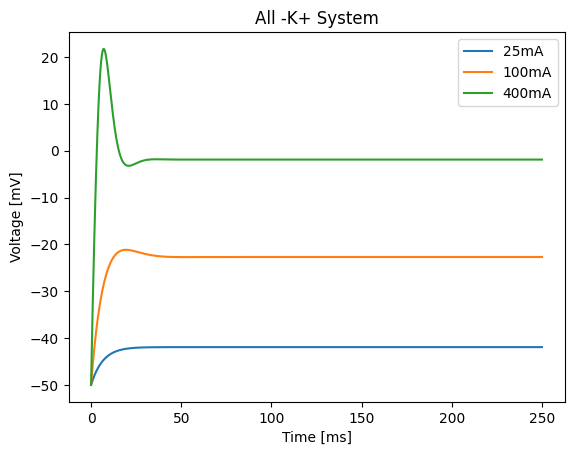

In [99]:
N_sim1.plot_V("25mA")
N_sim2.plot_V("100mA")
N_sim3.plot_V("400mA")
plt.xlabel("Time [ms]")
plt.ylabel("Voltage [mV]")
plt.title("All -K+ System")
plt.legend()

## Figure 5A

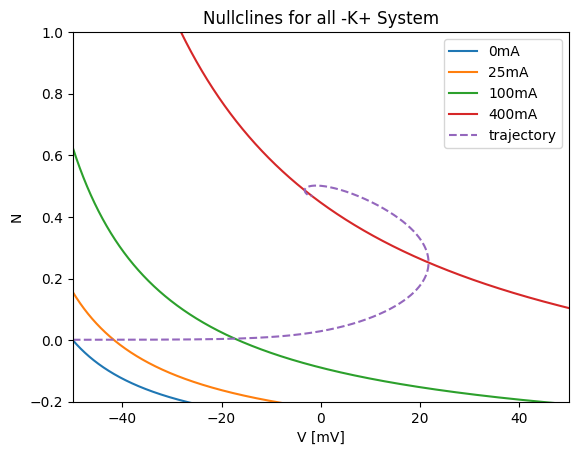

In [139]:
N_sim0.plot_Vnullcline("0mA")
N_sim1.plot_Vnullcline("25mA")
N_sim2.plot_Vnullcline("100mA")
N_sim3.plot_Vnullcline("400mA")

N_sim3.plot_trajectory("trajectory")

plt.xlim(-50,50)
plt.ylim(-.2,1)

plt.ylabel("N")
plt.xlabel("V [mV]")
plt.title("Nullclines for all -K+ System")
plt.legend()

## Figure 6

ValueError: '+' is not a valid value for ls; supported values are '-', '--', '-.', ':', 'None', ' ', '', 'solid', 'dashed', 'dashdot', 'dotted'

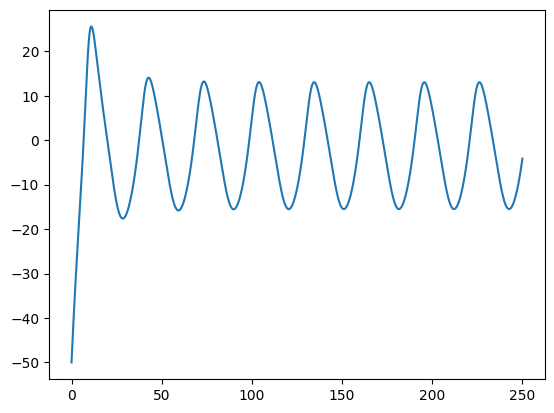

In [ ]:
V_solid.plot_V(label="solid")
V_broken.plot_V(label="broken",marker="+",linestyle=None)

## Figure 7